<a href="https://colab.research.google.com/github/Tanseychuong/lab_2_predictive_analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Chuong Tiutiu Nyang Mayian
**Student ID:** 25932028

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [55]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64
Negative Tips:
 0
Invalid Distance
 76
Negative Fare:
 0


(0.0, 30.0)

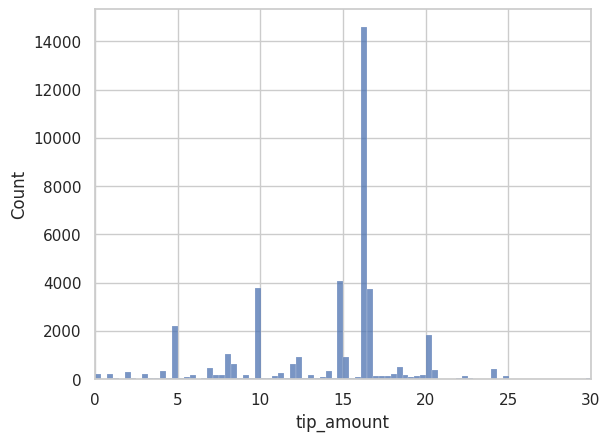

In [56]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
#taxi.shape, taxi.head(), taxi.info()
taxi.describe()
# - count missing values per column:
missing_count = taxi.isna().sum() # counting missing values
print(missing_count) #reporting the missing values

negative_tips = (taxi['tip_amount'] < 0).sum()
print('Negative Tips:\n',negative_tips)

invalid_distance = (taxi['trip_distance'] <= 0).sum()
print('Invalid Distance\n',invalid_distance)

negative_fares = (taxi['fare_amount'] < 0).sum()
print('Negative Fare:\n',negative_fares)
# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

ax = sns.histplot(taxi['tip_amount'])
ax.set_xlim(0, 30)

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:**
## Shape of the histogram
The dataset has (insert taxi.shape[0]) rows and (insert taxi.shape[1]) columns. The missing value check shows that there are no missing values in any of the columns.
## Missing Values
To assess data quality, I checked for impossible or suspicious values. There are negative_tips negative tip values, invalid_distance trips with zero or negative distance, and negative_fares negative fare values. These records should be investigated and may need to be removed or corrected before training a model because they do not represent valid taxi trips.
## Imposible values
The distribution of tip_amount is highly right-skewed. Most trips have small tips (including many zero or near-zero tips), while a small number of trips have very large tips that appear as outliers. This means the data are not normally distributed.
## Tip Amount
This distribution will influence preprocessing. Invalid records should be removed, and because of the skewness and outliers, techniques such as a log transformation of the target (where appropriate) or robust scaling for numerical features may improve model performance. Outliers should also be examined to determine whether they are genuine observations or data-entry errors.



### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [57]:
# TODO: Handle missing / invalid rows
# Remove invalid rows

#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi.dropna()
taxi = taxi[taxi['trip_distance'] > 0]
taxi = taxi[taxi['fare_amount'] > 0]
taxi = taxi[taxi['tip_amount'] >= 0]


# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

#Engineering the features for creating the justified feature
taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']

taxi['total_surcharges'] = (
    taxi['mta_tax']
    + taxi['tolls_amount']
    + taxi['improvement_surcharge']
)


# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

# Encode binary feature
taxi['store_and_fwd_flag'] = taxi['store_and_fwd_flag'].map({'Y': 1, 'N': 0})
taxi['store_and_fwd_flag'] = taxi['store_and_fwd_flag'].fillna(0)

taxi = pd.get_dummies(
    taxi,
    columns=['VendorID', 'RatecodeID', 'payment_type'],
    drop_first=True
)

X = taxi.drop(columns=['tip_amount'])
y = taxi['tip_amount']



# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Define numeric_cols as a list of strings
numeric_cols = [
    'trip_distance',
    'fare_amount',
    'passenger_count',
    'fare_per_mile',
    'total_surcharges'
]


**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:** [Double-click to edit]


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [58]:
# TODO: Separate features (X) and target (y = tip_amount)
y = taxi['tip_amount']
X = taxi.drop(columns=['tip_amount'])
# TODO: Split into train / validation / test (a common choice is 60/20/20).
train_size = 0.6
val_size = 0.2
test_size = 0.2

from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_size, random_state=RANDOM_STATE
)
# Split the remaining data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,   # 25% of the remaining 80% = 20% of the original data
    random_state=RANDOM_STATE
)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
scaler.fit(X_train[numeric_cols])

numeric_cols = [
    'trip_distance',
    'fare_amount',
    'passenger_count',
    'fare_per_mile',
    'total_surcharges'
]

# Fit only on the training data
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Use the same scaler for validation and test data
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:**
## 1. Used Ration
I used a 60:20:20 split for the dataset, where 60% of the data was used for training, 20% for validation, and 20% for testing. This provides enough data for the model to learn while reserving separate datasets for model tuning and final evaluation.
## 2. Why test validation is usefull
A separate validation set is used to evaluate the model during development and to select the best model without the test set. This prevent overfitting to the training data. The test set is then used at the end to provide an unbiased estimate of the final model performance on unseen data.
## 3. Fitting the scaler in the data
The scaler is fitted only on the training data to prevent data leakage. If the scaler were fitted using the validation or test data, information from those datasets would influence the training process, which lead to overy optimistic results. By fitting the scaler only on the training set and then applying the same transformation to the validation and test sets, the model is evaluated on truly unseen data, providing a fair and realistic estimate of its performance.

### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

Training RMSE: 4.804467061590075
Validation RMSE: 5.037203788341922
Test RMSE: 5.01298337807929
Training R²: 0.051322228045776574
Validation R²: 0.04860915807474753
Test R²: 0.051136087913852935


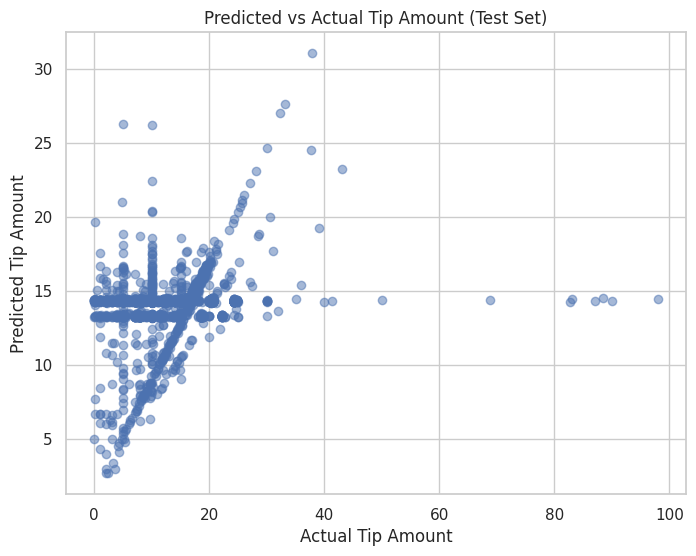

Random Forest Test RMSE: 5.612222972595981
Random Forest Test R²: -0.18927211109732323


In [59]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# TODO: Predict on train, validation, and test sets.
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
linear_reg.score(X_train, y_train)

y_train_pred = linear_reg.predict(X_train)
y_val_pred = linear_reg.predict(X_val)
y_test_pred = linear_reg.predict(X_test)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

#Train the model using the rmse, (regression mean score error)
train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
val_rmse = mean_squared_error(y_val, y_val_pred) ** 0.5
test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5

#Train the model on the r-square score
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)
print("Test RMSE:", test_rmse)

print("Training R²:", train_r2)
print("Validation R²:", val_r2)
print("Test R²:", test_r2)

#min_val = min(y_test.min(), y_test_pred.min())
#max_val = max(y_test.max(), y_test_pred.max())

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, alpha=0.5)

#plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Predicted vs Actual Tip Amount (Test Set)")

plt.show()

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

rf_test_pred = rf.predict(X_test)

rf_rmse = mean_squared_error(y_test, rf_test_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest Test RMSE:", rf_rmse)
print("Random Forest Test R²:", rf_r2)

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:**

## 1. Performance Measure
The Linear Regression model performed best on the validation set, as it achieved a validation RMSE of 5.04 and an R² of 0.049. The Random Forest model performed worse, with a higher test RMSE of 5.61 and a negative R² of -0.189.
## 2. Train vs Validation vs Test comparation of metrics
The Linear Regression model shows similar performance across all datasets, with a training RMSE of 4.80, validation RMSE of 5.04, and test RMSE of 5.01. The R² values are also consistently low around 0.05. This indicates that the model is underfitting, not overfitting, since performance is consistently poor across training and validation sets rather than significantly better on training data.

## 3. My take on what could reduce the overfitting if seen
Increasing model complexity and add more informative feature engineering

---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

Obesity Desc:                 Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.312600     1.701677    86.586058     2.419043     2.685628   
std       6.345968     0.093305    26.191172     0.533927     0.778039   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.947192     1.630000    65.473343     2.000000     2.658738   
50%      22.777890     1.700499    83.000000     2.385502     3.000000   
75%      26.000000     1.768464   107.430682     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008011     1.010298     0.657866  
std       0.612953     0.850592     0.608927  
min       1.000000     0.000000     0.000000  
25%       1.584812     0.124505     0.000000  
50%       2.000000     1.000000     

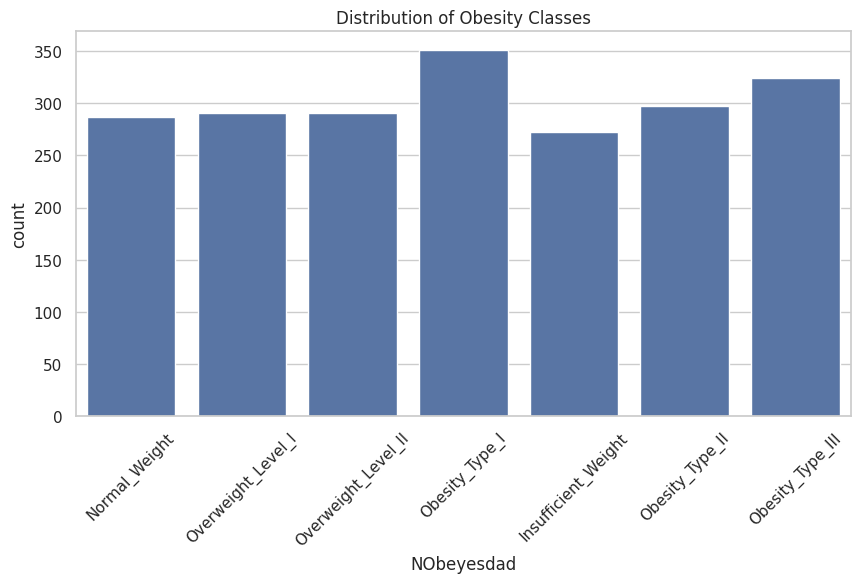

In [60]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print("Obesity Desc: ",obesity.describe())
print("Head: ",obesity.head())
print("Info: ",obesity.info())
print("Shape: ",obesity.shape)
print("Missing Values:",obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`

print("\nClass distribution:")
print(obesity['NObeyesdad'].value_counts())

plt.figure(figsize=(10,5))
sns.countplot(data=obesity, x='NObeyesdad')
plt.xticks(rotation=45)
plt.title("Distribution of Obesity Classes")
plt.show()
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?


**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:**
## Categorical and numeric features

The dataset contains 2111 rows and 17 features describing individual health and lifestyle information.

The dataset includes both categorical variables such as gender and numerical variables like age and weight.
### Numerical features:

Age
Height
Weight
FCVC
NCP
CH2O
FAF
TUE

### Categorical features:

Gender
family_history_with_overweight
FAVC
CAEC
SMOKE
SCC
CALC
MTRANS
NObeyesdad (target variable)

## Class distribution (target variable)
The target variable has seven classes representing obesity levels with fairly similar sample sizes across classes. Although the dataset is mostly balanced, some classes have slightly more or fewer samples than others.
Class imbalance matters because it can bias models toward majority classes and reduce minority class accuracy.
Overall, this dataset is suitable for classification with minimal risk of severe imbalance issues.

### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [61]:
from sklearn.preprocessing import OrdinalEncoder
obesity = pd.read_csv(OBESITY_URL)

# Binary columns
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})
    obesity[col] = obesity[col].fillna(0) # filling the NaN values

ordinal_cols = ['CAEC', 'CALC']

ordinal_encoder = OrdinalEncoder(
    categories=[['no', 'Sometimes', 'Frequently', 'Always'],
                ['no', 'Sometimes', 'Frequently', 'Always']
                ]
    )
obesity[ordinal_cols] = ordinal_encoder.fit_transform(obesity[ordinal_cols])

obesity = pd.get_dummies(
    obesity,
    columns=['Gender', 'MTRANS'],
    drop_first=True
)


# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)
'''BMI is very predictive of obesity level, so it may make the task easier
and reduce the need for other features, but it is still a realistic medical feature. There is a likelihood that it might leaks the target'''

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

obesity['NObeyesdad_encoded'] = label_encoder.fit_transform(obesity['NObeyesdad'])
obesity = obesity.drop(columns=['NObeyesdad'])


# TODO: Scale the numeric features (fit on TRAIN only, in Part.
numeric_features = [
    'Age', 'Height', 'Weight',
    'FCVC', 'NCP', 'CH2O',
    'FAF', 'TUE',
    'BMI'
]


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:**

I encoded binary variables such as family history, FAVC, SMOKE, and SCC using 0/1 mapping because they represent yes/no information. Ordinal variables like CAEC and CALC were encoded using ordinal encoding since they have a natural order. Nominal variables such as Gender and MTRANS were encoded using one-hot encoding because they do not have an inherent ranking.

I engineered a BMI feature using weight divided by height squared, as it is a strong indicator of obesity. While BMI makes the prediction task easier because it is directly related to obesity levels, it is still a realistic and meaningful health metric, so its inclusion is justified.

I used standard scaling for numerical features because it ensures all variables are on a comparable scale, which improves model stability and performance for algorithms sensitive to feature magnitude.


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [62]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X = obesity.drop(columns=['NObeyesdad_encoded'])
y = obesity['NObeyesdad_encoded']
# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
from sklearn.model_selection import train_test_split

# Split the remaining data into training and validation sets

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,  # 0.25 of 80% = 20%
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
scaler = StandardScaler()

numeric_cols = [
    'Age', 'Height', 'Weight',
    'FCVC', 'NCP', 'CH2O',
    'FAF', 'TUE',
    'BMI'
]
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:**

I used a 60:20:20 split ratio for training, validation, and testing the dataset. This ensures enough data for learning while keeping separate sets for model tuning and final evaluation.

The `stratify=y` parameter is very important to ensures that all classes are represented proportionally in every split. This prevents class underrepresentation or missing in any subset.

If not stratify, random splitting could lead to imbalanced subsets where some classes appear very rarely or not at all. This would bias the model and make evaluation unreliable, especially for minority classes.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

Train Accuracy: 0.9281
Train Macro-F1: 0.9258

Validation Accuracy: 0.8839
Validation Macro-F1: 0.8779

Test Accuracy: 0.9007
Test Macro-F1: 0.8972



<Figure size 1000x800 with 0 Axes>

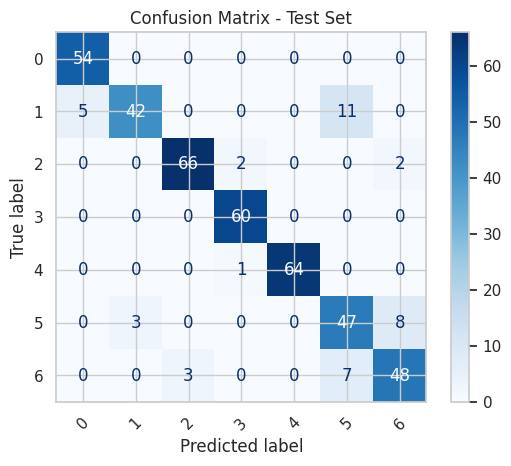

In [63]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

max_iter = 1000
classifier = LogisticRegression(max_iter=max_iter)

classifier.fit(X_train, y_train)

# TODO: Predict on train, validation, and test.

y_train_pred = classifier.predict(X_train)
y_val_pred = classifier.predict(X_val)
y_test_pred = classifier.predict(X_test)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{name} Accuracy: {acc:.4f}")
    print(f"{name} Macro-F1: {f1:.4f}\n")

evaluate(y_train, y_train_pred, "Train")
evaluate(y_val, y_val_pred, "Validation")
evaluate(y_test, y_test_pred, "Test")

# Confusion Matrix

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap="Blues",
    xticks_rotation=45
)
plt.title("Confusion Matrix - Test Set")
plt.show()

**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:**

I chose `Logistic Regression` because it is a strong baseline model for multiclass classification and works well with linearly separable patterns after scaling.

The model shows similar performance across all splits: training accuracy/F1 is slightly higher than validation and test, but all metrics are close. This indicates the model is *well-fitted with mild underfitting*, since performance is consistent and not highly accurate only on training and poor on validation.

From the confusion matrix, the most commonly confused classes are `Overweight_Level_I` and `Overweight_Level_II`, as well as `Obesity_Type_I` and `Obesity_Type_II`. These are harder to distinguish because they represent adjacent severity levels with very similar BMI and lifestyle characteristics, causing overlapping feature patterns.


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


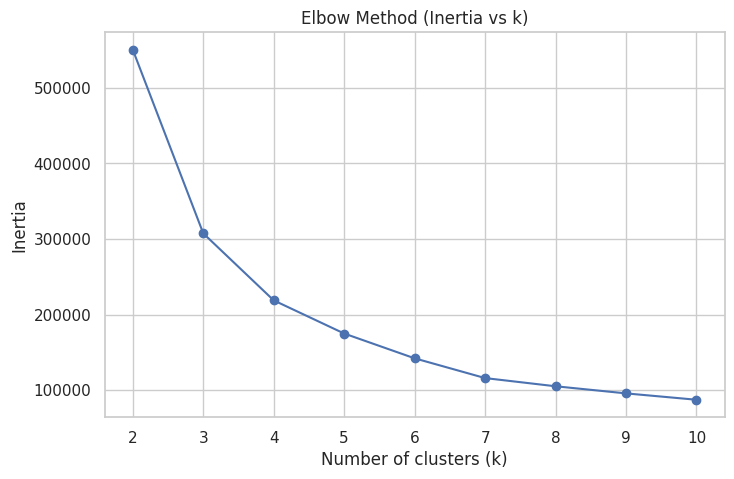

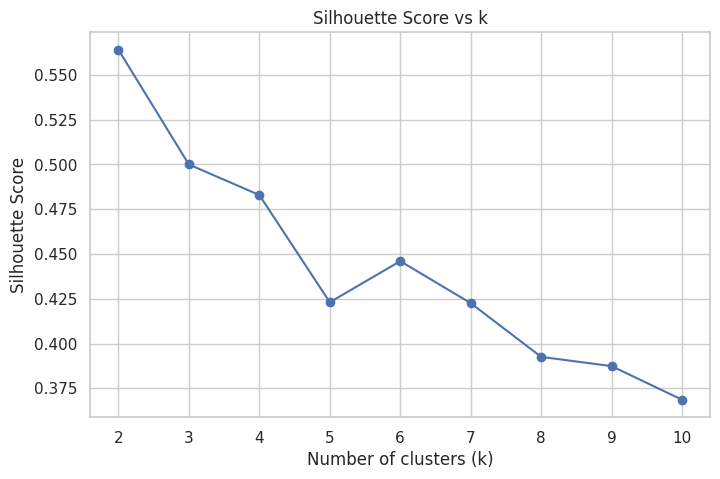

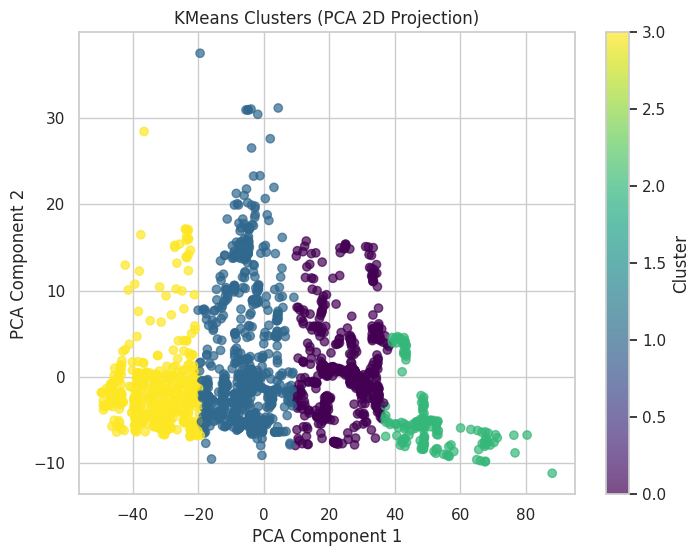

In [53]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
obesity_features = obesity.drop(columns=['NObeyesdad_encoded'])

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

inertias = []
silhouettes = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(obesity_features)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(obesity_features, kmeans.labels_))

plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method (Inertia vs k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

print("")
# Plot Silhouette Score
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouettes, marker='o')
plt.title("Silhouette Score vs k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()
print("")

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

best_k = 4  # change based on your plots

final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = final_kmeans.fit_predict(obesity_features)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
pca = PCA(n_components=2)
reduced = pca.fit_transform(obesity_features)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.title("KMeans Clusters (PCA 2D Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

In [54]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
# Cross-tab: cluster assignment vs true obesity class
import pandas as pd

# Cluster vs true labels (human-readable version)
# Use the NObeyesdad_encoded column and inverse_transform to get original labels
cluster_vs_true = pd.crosstab(
    cluster_labels,
    label_encoder.inverse_transform(obesity['NObeyesdad_encoded'])
)

print(cluster_vs_true)

col_0  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  \
row_0                                                                        
0                        0              0             144              271   
1                        0             76             206                1   
2                        0              0               1               25   
3                      272            211               0                0   

col_0  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II  
row_0                                                             
0                   181                   0                   17  
1                     0                 228                  252  
2                   143                   0                    0  
3                     0                  62                   21  


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:** **Answer:**

The value of **k was selected using both the elbow method and silhouette scores**. The elbow plot showed a noticeable bend around *k = 4 to 5*, where the reduction in inertia began to slow down significantly. In addition, the silhouette scores were relatively higher in this same range, suggesting better-defined clusters without over-segmenting the data.

From the crosstab analysis, the unsupervised clusters only partially match the true obesity levels. There is reasonable agreement for extreme cases such as higher obesity categories, where individuals naturally group together due to strong signals like BMI and weight. However, the clusters break down when separating adjacent categories like Overweight_Level_I and Overweight_Level_II, which frequently overlap in feature space and are not cleanly separable without labels.

In a public-health setting, these clusters would still be very useful even without labeled data. They can help identify broad risk groups, support early intervention strategies, and reduce the need for expensive manual classification. They are especially valuable for discovering hidden patterns in population health data that may not be obvious from predefined categories.



---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:**

> **1. Supervised vs Unsupervised**
 The biggest train–test gap appeared in the clustering and regression tasks, where performance differences were small or inconsistent improvements, but overall model quality was limited. The most effective improvement would be better feature engineering and stronger models (e.g. gradient boosting), along with careful tuning and regularization to improve generalization.

> **2. Regression vs classification**
>In regression (tips), performance was evaluated using error-based metrics like RMSE and R², which measure how close predictions are to exact numerical values. In classification (obesity), evaluation focused on correctness of discrete labels using accuracy, macro-F1, and confusion matrices, which assess how well the model separates categories rather than predicting exact values.

> **3. Overfitting**
>The classifier learned explicit boundaries between the true obesity classes using labeled data, allowing it to directly optimize for correct category prediction. K-Means, on the other hand, grouped individuals based only on feature similarity without knowing the labels, so it could only capture general structure (like BMI-based groupings) but not the actual obesity categories.
>


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
